In [17]:
# Install boto3 and python-dotenv if not already installed
!pip install boto3 python-dotenv pandas matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [5]:
# ==========================================
# 1. Setup – Import libraries and configs
# ==========================================
import requests
import time
import json
import boto3
import os
from botocore.exceptions import NoCredentialsError
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

EMAIL = "l.xuanzhen@wustl.edu"     
API_KEY = "saffronram57"   
YEARS = [str(y) for y in range(2001, 2024)]  # 2001-2023

# ---- S3 Configuration ----
# Load keys from environment variables
AWS_ACCESS_KEY = os.getenv('AWS_S3_ACCESS_KEY')
AWS_SECRET_KEY = os.getenv('AWS_S3_SECRET_ACCESS_KEY')
S3_BUCKET_NAME = os.getenv('AWS_S3_BUCKET_NAME')
S3_REGION = os.getenv('AWS_REGION', 'us-east-1')

# ---- City List ----
CITIES_TO_ANALYZE = [
    {"name": "New York City", "state": "36", "county": "061"},       # New York County (Manhattan)
    {"name": "Washington D.C.", "state": "11", "county": "001"},
    {"name": "San Francisco", "state": "06", "county": "075"},
    {"name": "Los Angeles", "state": "06", "county": "037"},
    {"name": "Chicago", "state": "17", "county": "031"},
    {"name": "Houston", "state": "48", "county": "201"},              # Harris County
    {"name": "Miami", "state": "12", "county": "086"},                # Miami-Dade
    {"name": "Minneapolis", "state": "27", "county": "053"},          # Hennepin County
    {"name": "Denver", "state": "08", "county": "031"},
    {"name": "Seattle", "state": "53", "county": "033"},              # King County
    {"name": "Atlanta", "state": "13", "county": "121"},              # Fulton County
    {"name": "Boston", "state": "25", "county": "025"},               # Suffolk County
    {"name": "St. Louis", "state": "29", "county": "510"}             # St. Louis City (independent)
]

# ---- List of Pollutants
PARAMS_TO_ANALYZE = [
    {"name": "PM2.5", "code": "88101"},
    {"name": "Ozone", "code": "44201"},
    {"name": "NO2", "code": "42602"}
]

In [6]:
# ==========================================
# 2. Define a general data retrieval function数
# ==========================================
import os

def upload_to_s3(local_file, bucket, s3_file):
    """
    Upload a file to an S3 bucket
    """
    # If keys are not provided (still default placeholders), skip upload
    if AWS_ACCESS_KEY == 'YOUR_ACCESS_KEY' or AWS_SECRET_KEY == 'YOUR_SECRET_KEY':
        print("⚠️ S3 Keys not configured. Skipping upload.")
        return False

    s3 = boto3.client('s3', aws_access_key_id=AWS_ACCESS_KEY,
                      aws_secret_access_key=AWS_SECRET_KEY,
                      region_name=S3_REGION)
    try:
        s3.upload_file(local_file, bucket, s3_file)
        print(f"☁️ Uploaded to S3: s3://{bucket}/{s3_file}")
        return True
    except FileNotFoundError:
        print("❌ The file was not found")
        return False
    except NoCredentialsError:
        print("❌ Credentials not available")
        return False
    except Exception as e:
        print(f"❌ S3 Upload error: {e}")
        return False

def fetch_epa_data(endpoint, years_list, state_code, county_code, param_code, city_name=None, param_name=None):
    base_url = "https://aqs.epa.gov/data/api/"
    full_url = base_url + endpoint

    save_folder = "epa_data"
    os.makedirs(f"./data/{save_folder}", exist_ok=True)
    file_path = f"./data/{save_folder}/{city_name}_{param_name}.json"

# ===== If a data file already exists locally, read it directly. =====
    if os.path.exists(file_path):
        print(f"✅ Cache already exists: {file_path}, reading...")
        
        # Try to upload existing cache to S3 as well
        if S3_BUCKET_NAME and S3_BUCKET_NAME != 'your-bucket-name':
             s3_object_name = f"epa_data/{os.path.basename(file_path)}"
             upload_to_s3(file_path, S3_BUCKET_NAME, s3_object_name)
             
        with open(file_path, "r", encoding="utf-8") as f:
            return json.load(f)

    pollutant_data = []

    for year in years_list:
        bdate = f"{year}0101"
        edate = f"{year}1231"
        params = {
            "email": EMAIL,
            "key": API_KEY,
            "param": param_code,
            "bdate": bdate,
            "edate": edate,
            "state": state_code,
            "county": county_code
        }

        try:
            response = requests.get(full_url, params=params)
            if response.status_code == 200:
                data = response.json()
                if data.get("Data"):
                    pollutant_data.extend(data["Data"])
            else:
                print(f"⚠️ Request for {year} failed, status code: {response.status_code}")
        except requests.exceptions.RequestException as e:
            print(f"❌ Network error: {e}")

    # ===== Save to local file after download =====
    with open(file_path, "w", encoding="utf-8") as f:
        json.dump(pollutant_data, f, indent=2)

    print(f"✅ Data has been saved to:{file_path}")
    
    # ===== Upload to S3 =====
    if S3_BUCKET_NAME and S3_BUCKET_NAME != 'your-bucket-name':
         s3_object_name = f"epa_data/{os.path.basename(file_path)}"
         upload_to_s3(file_path, S3_BUCKET_NAME, s3_object_name)

    return pollutant_data

In [7]:
all_cities_annual_data = {}
all_cities_daily_data = {}

for city in CITIES_TO_ANALYZE:
    city_name = city["name"]
    state = city["state"]
    county = city["county"]
    
    print(f"\n======= Start processing the city: {city_name} =======")
    # Initialize an empty dictionary for the current city.
    all_cities_annual_data.setdefault(city_name, {})
    all_cities_daily_data.setdefault(city_name, {})

    for param in PARAMS_TO_ANALYZE:
        param_name = param["name"]
        param_code = param["code"]
        print(f"--- Retrieving data for {param_name} ---")
        
        # Get annual data + save
        annual_data = fetch_epa_data("annualData/byCounty", YEARS, state, county, param_code, city_name, param_name)
        daily_data = fetch_epa_data("dailyData/byCounty", YEARS, state, county, param_code, city_name, param_name)
        all_cities_annual_data[city_name][param_name] = annual_data
        print(f"  {param_name} Annual data retrieval complete, totaling {len(annual_data)} records.")
        
        # Get daily data + save
        daily_data = fetch_epa_data("dailyData/byCounty", YEARS, state, county, param_code)
        all_cities_daily_data[city_name][param_name] = daily_data
        print(f"  {param_name} Daily data retrieval complete, totaling {len(daily_data)} records.")

print("\n\n======= Data for all cities and pollutants has been acquired! =======")


======= Start processing the city: New York City =======
--- Retrieving data for PM2.5 ---
✅ Cache already exists: ./data/epa_data/New York City_PM2.5.json, reading...
☁️ Uploaded to S3: s3://tuez-avatar/epa_data/New York City_PM2.5.json
✅ Cache already exists: ./data/epa_data/New York City_PM2.5.json, reading...
☁️ Uploaded to S3: s3://tuez-avatar/epa_data/New York City_PM2.5.json
✅ Cache already exists: ./data/epa_data/New York City_PM2.5.json, reading...
☁️ Uploaded to S3: s3://tuez-avatar/epa_data/New York City_PM2.5.json
  PM2.5 Annual data retrieval complete, totaling 904 records.
☁️ Uploaded to S3: s3://tuez-avatar/epa_data/New York City_PM2.5.json
  PM2.5 Annual data retrieval complete, totaling 904 records.
✅ Data has been saved to:./data/epa_data/None_None.json
✅ Data has been saved to:./data/epa_data/None_None.json
☁️ Uploaded to S3: s3://tuez-avatar/epa_data/None_None.json
  PM2.5 Daily data retrieval complete, totaling 82030 records.
--- Retrieving data for Ozone ---
✅ Ca

In [16]:
# ==========================================
# 4. Analysis and Visualization (Multi-city, Multi-pollutant Version)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_each_city_each_pollutant_trend(all_cities_annual_data):
    for city_name, pollutant_dict in all_cities_annual_data.items():
        for pollutant_name, pollutant_data in pollutant_dict.items():
            if not pollutant_data:
                print(f"⚠️ Skipping {city_name} - {pollutant_name}: No data available.")
                continue

            df = pd.DataFrame(pollutant_data)
            df['arithmetic_mean'] = pd.to_numeric(df['arithmetic_mean'], errors='coerce')
            df['year'] = pd.to_numeric(df['year'], errors='coerce')
            df.dropna(subset=['arithmetic_mean', 'year'], inplace=True)

            if df.empty:
                print(f"❌ No valid values for {city_name} - {pollutant_name}")
                continue

            yearly_avg = df.groupby('year')['arithmetic_mean'].mean().reset_index()

            plt.figure(figsize=(10, 6))
            sns.lineplot(data=yearly_avg, x='year', y='arithmetic_mean', marker='o')
            unit = "µg/m³" if pollutant_name == "PM2.5" else "ppm"
            plt.title(f"{city_name} - {pollutant_name} Trend (2001–2023)", fontsize=16)
            plt.xlabel("Year")
            plt.ylabel(f"{pollutant_name} (avg {unit})")
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.tight_layout()
            plt.show()

# ==========================================
# 5. Generate charts for each city and each pollutant in a loop.
# ==========================================
plot_each_city_each_pollutant_trend(all_cities_annual_data)

Matplotlib is building the font cache; this may take a moment.


ModuleNotFoundError: No module named 'seaborn'

In [16]:
import os

folder = "epa_data"
files = os.listdir(folder)
total_size = 0

print(f"📂 Folder '{folder}' contains {len(files)} files:\n")
for f in files:
    size = os.path.getsize(os.path.join(folder, f))
    total_size += size
    print(f"{f:40} {size/1024:.2f} KB")

print(f"\nTotal size: {total_size/1024/1024:.2f} MB")

📂 Folder 'epa_data' contains 40 files:

Denver_NO2.json                          208.49 KB
Denver_PM2.5.json                        2464.70 KB
Atlanta_PM2.5.json                       1074.21 KB
New York City_PM2.5.json                 1747.44 KB
San Francisco_PM2.5.json                 426.41 KB
Chicago_PM2.5.json                       5322.69 KB
Houston_NO2.json                         1089.94 KB
Minneapolis_Ozone.json                   84.83 KB
Atlanta_NO2.json                         74.45 KB
St. Louis_PM2.5.json                     3055.04 KB
Boston_PM2.5.json                        3046.99 KB
San Francisco_NO2.json                   95.71 KB
Washington D.C._Ozone.json               593.83 KB
New York City_NO2.json                   34.40 KB
None_None.json                           84395.24 KB
Seattle_Ozone.json                       721.20 KB
Miami_Ozone.json                         442.04 KB
Miami_NO2.json                           207.61 KB
Los Angeles_PM2.5.json               

In [13]:
import pandas as pd
import glob, json

files = glob.glob("epa_data/*.json")
all_data = []

for file in files:
    with open(file, "r") as f:
        data = json.load(f)
        # 不再检查 "Data"，直接扩展列表
        if isinstance(data, list):
            all_data.extend(data)
        elif isinstance(data, dict) and "Data" in data:
            all_data.extend(data["Data"])

df = pd.DataFrame(all_data)

print("✅ Loaded data shape:", df.shape)
print("✅ Columns:", df.columns.tolist())
df.head(3)

✅ Loaded data shape: (0, 0)
✅ Columns: []


""


In [14]:
df = df.rename(columns={
    "city": "City",
    "year": "Year",
    "parameter": "Pollutant",
    "arithmetic_mean": "Value"
})

df = df[["City", "Year", "Pollutant", "Value", "state", "county"]]
df = df.dropna(subset=["City", "Value"])
df.head()

KeyError: "None of [Index(['City', 'Year', 'Pollutant', 'Value', 'state', 'county'], dtype='object')] are in the [columns]"

In [10]:
main_cities = [
    "New York", "Washington", "San Francisco", "Los Angeles", "Chicago",
    "Houston", "Miami", "Minneapolis", "Denver", "Seattle", "Atlanta",
    "Boston", "St. Louis"
]

df_main = df[df["City"].isin(main_cities)]
print(df_main["City"].unique())

NameError: name 'df' is not defined

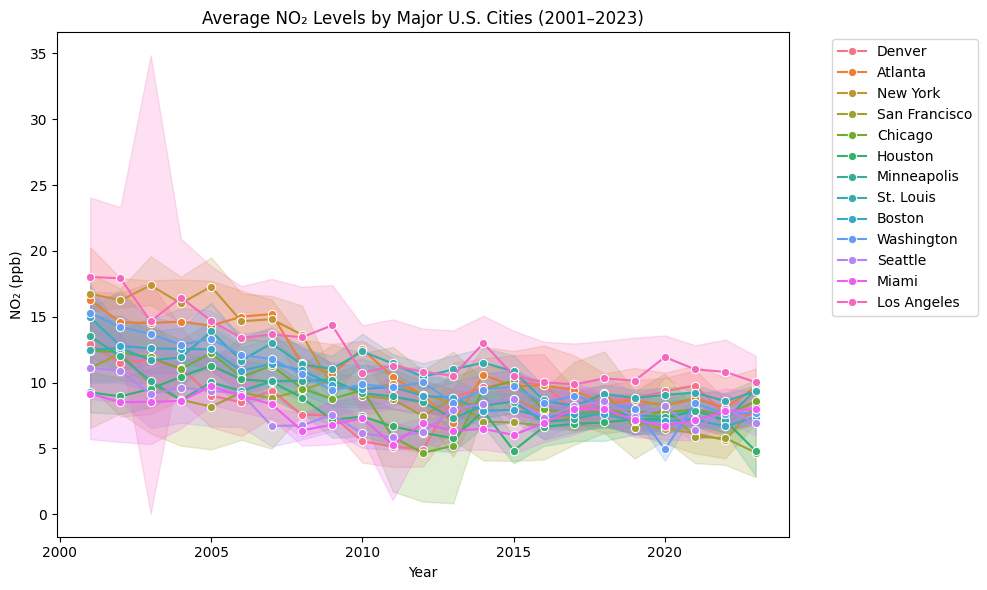

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.lineplot(data=df_main, x="Year", y="Value", hue="City", marker="o")
plt.title("Average NO₂ Levels by Major U.S. Cities (2001–2023)")
plt.ylabel("NO₂ (ppb)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()